In [2]:
from collections import OrderedDict
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from datasets.utils.logging import disable_progress_bar
from torch.utils.data import DataLoader

import flwr
from flwr.client import Client, ClientApp, NumPyClient
from flwr.common import Metrics, Context
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg
from flwr.simulation import run_simulation
from flwr_datasets import FederatedDataset

# DEVICE = torch.device("cpu") 
DEVICE = torch.device("cuda") # Try "cuda" to train on GPU
print(f"Training on {DEVICE}")
print(f"Flower {flwr.__version__} / PyTorch {torch.__version__}")
disable_progress_bar()

/home/ehsan/miniconda3/envs/flower/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-01-15 14:06:00.975346: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736978760.987442  414802 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736978760.991131  414802 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-15 14:06:01.003270: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-cr

Training on cuda
Flower 1.14.0 / PyTorch 2.5.1


In [3]:
NUM_CLIENTS = 3
BATCH_SIZE = 32


def load_datasets(partition_id: int):
    fds = FederatedDataset(dataset="cifar10", partitioners={"train": NUM_CLIENTS})
    partition = fds.load_partition(partition_id)
    # Divide data on each node: 80% train, 20% test
    partition_train_test = partition.train_test_split(test_size=0.2, seed=42)
    pytorch_transforms = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )

    def apply_transforms(batch):
        # Instead of passing transforms to CIFAR10(..., transform=transform)
        # we will use this function to dataset.with_transform(apply_transforms)
        # The transforms object is exactly the same
        batch["img"] = [pytorch_transforms(img) for img in batch["img"]]
        return batch

    # Create train/val for each partition and wrap it into DataLoader
    partition_train_test = partition_train_test.with_transform(apply_transforms)
    trainloader = DataLoader(
        partition_train_test["train"], batch_size=BATCH_SIZE, shuffle=True
    )
    valloader = DataLoader(partition_train_test["test"], batch_size=BATCH_SIZE)
    testset = fds.load_split("test").with_transform(apply_transforms)
    testloader = DataLoader(testset, batch_size=BATCH_SIZE)
    return trainloader, valloader, testloader

In [4]:
# Define a function to load the server test dataset and DataLoader
def load_server_test_dataset():
    fds = FederatedDataset(dataset="cifar10", partitioners={})  # Empty dict for no partitioning
    
    # Load the global test dataset
    testset = fds.load_split("test")

    # Apply the same transforms as for the clients
    pytorch_transforms = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )

    def apply_transforms(batch):
        batch["img"] = [pytorch_transforms(img) for img in batch["img"]]
        return batch

    # Apply transforms to the test dataset
    testset = testset.with_transform(apply_transforms)

    # Create a DataLoader for the server test dataset
    testloader = DataLoader(testset, batch_size=BATCH_SIZE)

    return testloader

In [5]:
def summarize_dataloader(dataloader):
    print("=== DataLoader Summary ===")
    # Dataset length
    dataset_size = len(dataloader.dataset)
    print(f"Total samples: {dataset_size}")
    
    # Batch size
    batch_size = dataloader.batch_size
    print(f"Batch size: {batch_size}")
    
    # Number of batches
    num_batches = len(dataloader)
    print(f"Number of batches: {num_batches}")
    
    # Inspect a single batch
    for i, batch in enumerate(dataloader):
        print(f"Inspecting Batch {i+1}:")
        for key, value in batch.items():
            if isinstance(value, (list, tuple)):
                print(f"  {key}: List/Tuple of length {len(value)}")
            else:
                print(f"  {key}: Shape {value.shape}, Type {value.dtype}")
        # Only inspect the first batch
        break
    print("===========================")
server_testloader = load_server_test_dataset()
summarize_dataloader(server_testloader)


=== DataLoader Summary ===
Total samples: 10000
Batch size: 32
Number of batches: 313
Inspecting Batch 1:
  img: Shape torch.Size([32, 3, 32, 32]), Type torch.float32
  label: Shape torch.Size([32]), Type torch.int64


/home/ehsan/miniconda3/envs/flower/lib/python3.12/site-packages/datasets/utils/_dill.py:385: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  obj.co_lnotab,  # for < python 3.10 [not counted in args]


/home/ehsan/miniconda3/envs/flower/lib/python3.12/site-packages/datasets/utils/_dill.py:385: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  obj.co_lnotab,  # for < python 3.10 [not counted in args]


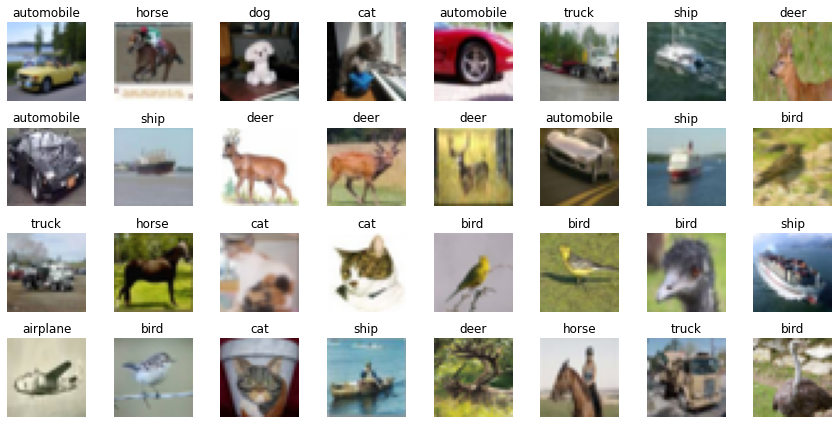

In [6]:
trainloader, _, _ = load_datasets(partition_id=0)
batch = next(iter(trainloader))
images, labels = batch["img"], batch["label"]

# Reshape and convert images to a NumPy array
# matplotlib requires images with the shape (height, width, 3)
images = images.permute(0, 2, 3, 1).numpy()

# Denormalize
images = images / 2 + 0.5

# Create a figure and a grid of subplots
fig, axs = plt.subplots(4, 8, figsize=(12, 6))

# Loop over the images and plot them
for i, ax in enumerate(axs.flat):
    ax.imshow(images[i])
    ax.set_title(trainloader.dataset.features["label"].int2str([labels[i]])[0])
    ax.axis("off")

# Show the plot
fig.tight_layout()
plt.show()

In [7]:
class Net(nn.Module):
    def __init__(self, num_classes=10) -> None:
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [8]:
def train(net, trainloader, epochs: int, verbose=False):
    """Train the network on the training set."""
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters())
    net.train()
    for epoch in range(epochs):
        correct, total, epoch_loss = 0, 0, 0.0
        for batch in trainloader:
            images, labels = batch["img"].to(DEVICE), batch["label"].to(DEVICE)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            # Metrics
            epoch_loss += loss
            total += labels.size(0)
            correct += (torch.max(outputs.data, 1)[1] == labels).sum().item()
        epoch_loss /= len(trainloader.dataset)
        epoch_acc = correct / total
        if verbose:
            print(f"Epoch {epoch+1}: train loss {epoch_loss}, accuracy {epoch_acc}")


def test(net, testloader, device=DEVICE):
    """Evaluate the network on the entire test set."""
    criterion = torch.nn.CrossEntropyLoss()
    correct, total, loss = 0, 0, 0.0
    net.to(device)
    net.eval()
    with torch.no_grad():
        for batch in testloader:
            images, labels = batch["img"].to(DEVICE), batch["label"].to(DEVICE)
            outputs = net(images)
            loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    loss /= len(testloader.dataset)
    accuracy = correct / total
    return loss, accuracy

In [8]:
trainloader, valloader, testloader = load_datasets(partition_id=0)
net = Net().to(DEVICE)

for epoch in range(3):
    train(net, trainloader, 1)
    loss, accuracy = test(net, valloader)
    print(f"Epoch {epoch+1}: validation loss {loss}, accuracy {accuracy}")

loss, accuracy = test(net, testloader)
print(f"Final test set performance:\n\tloss {loss}\n\taccuracy {accuracy}")

/home/ehsan/miniconda3/envs/flower/lib/python3.12/site-packages/datasets/utils/_dill.py:385: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  obj.co_lnotab,  # for < python 3.10 [not counted in args]


Epoch 1: validation loss 0.05206012228826741, accuracy 0.40221955608878224
Epoch 2: validation loss 0.04746145657171514, accuracy 0.45290941811637675
Epoch 3: validation loss 0.04524171931627773, accuracy 0.47690461907618475
Final test set performance:
	loss 0.04446471590995789
	accuracy 0.4779


In [9]:
def set_parameters(net, parameters: List[np.ndarray]):
    params_dict = zip(net.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
    net.load_state_dict(state_dict, strict=True)


def get_parameters(net) -> List[np.ndarray]:
    return [val.cpu().numpy() for _, val in net.state_dict().items()]

In [16]:
class FlowerClient(NumPyClient):
    def __init__(self, net, trainloader, valloader):
        self.net = net
        self.trainloader = trainloader
        self.valloader = valloader

    def get_parameters(self, config):
        return get_parameters(self.net)

    def fit(self, parameters, config):
        print(parameters)
        set_parameters(self.net, parameters)
        train(self.net, self.trainloader, epochs=1)
        loss, accuracy = test(self.net, self.trainloader)
        return get_parameters(self.net), len(self.trainloader), {"loss": loss, "accuracy":  float(accuracy)}


    def evaluate(self, parameters, config):
        set_parameters(self.net, parameters)
        loss, accuracy = test(self.net, self.valloader)
        return float(loss), len(self.valloader), {"accuracy": float(accuracy), "loss": float(loss)}
    
def client_fn(context: Context) -> Client:
    """Create a Flower client representing a single organization."""

    # Load model
    net = Net().to(DEVICE)

    # Load data (CIFAR-10)
    # Note: each client gets a different trainloader/valloader, so each client
    # will train and evaluate on their own unique data partition
    # Read the node_config to fetch data partition associated to this node
    partition_id = context.node_config["partition-id"]
    trainloader, valloader, _ = load_datasets(partition_id=partition_id)

    # Create a single Flower client representing a single organization
    # FlowerClient is a subclass of NumPyClient, so we need to call .to_client()
    # to convert it to a subclass of `flwr.client.Client`
    return FlowerClient(net, trainloader, valloader).to_client()


# Create the ClientApp
client = ClientApp(client_fn=client_fn)

In [11]:
def get_evaluate_fn(testloader):
    """Return a function that can be called to do global evaluation."""

    def evaluate_fn(server_round: int, parameters, config):
        """Evaluate global model on the whole test set."""

        model = Net(num_classes=10)
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        model.to(device)

        # set parameters to the model
        params_dict = zip(model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
        model.load_state_dict(state_dict, strict=True)

        # call test (evaluate model as in centralised setting)
        loss, accuracy = test(model, testloader, device)
        print(f"Round {server_round} - Evaluation: loss {loss}, accuracy {accuracy}")
        return loss, {"accuracy": accuracy, "loss": loss}

    return evaluate_fn

In [12]:
# Define metric aggregation function
def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    # print("\nPrinting metrics in weighted_average function \n {} \n".format(metrics))

    # Multiply accuracy of each client by number of examples used
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]

    # Aggregate and return custom metric (weighted average)
    return {"accuracy": sum(accuracies) / sum(examples)}

In [13]:
def fit_metrics_aggregation_fn(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    # print("\nPrinting metrics in fit_metrics_aggregation_fn function \n {} \n".format(metrics))


    # Multiply accuracy of each client by number of examples used
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    losses = [num_examples * m["loss"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, m in metrics]

    return {"accuracy": sum(accuracies) / sum(examples), "loss": sum(losses) / sum(examples)}

In [14]:
# Create FedAvg strategy
strategy = FedAvg(
    fraction_fit=1.0,  # Sample 100% of available clients for training
    fraction_evaluate=0.5,  # Sample 50% of available clients for evaluation
    min_fit_clients=3,  # Never sample less than 10 clients for training
    min_evaluate_clients=3,  # Never sample less than 5 clients for evaluation
    min_available_clients=3,
    evaluate_metrics_aggregation_fn=weighted_average, # callback defined earlier
    fit_metrics_aggregation_fn=fit_metrics_aggregation_fn,  # callback defined earlier
    evaluate_fn=get_evaluate_fn(
        server_testloader
    ),  # Wait until all 3 clients are available
)

def server_fn(context: Context) -> ServerAppComponents:
    """Construct components that set the ServerApp behaviour.

    You can use the settings in `context.run_config` to parameterize the
    construction of all elements (e.g the strategy or the number of rounds)
    wrapped in the returned ServerAppComponents object.
    """

    # Configure the server for 5 rounds of training
    config = ServerConfig(num_rounds=2)

    return ServerAppComponents(strategy=strategy, config=config)


# Create the ServerApp
server = ServerApp(server_fn=server_fn)

In [15]:
# Specify the resources each of your clients need
# By default, each client will be allocated 1x CPU and 0x GPUs
backend_config = {"client_resources": {"num_cpus": 1, "num_gpus": 0.0}}

# # When running on GPU, assign an entire GPU for each client
if DEVICE.type == "cuda":
    backend_config = {"client_resources": {"num_cpus": 1, "num_gpus": 0.2}}
    # Refer to our Flower framework documentation for more details about Flower simulations
    # and how to set up the `backend_config`

In [18]:
backend_config

{'client_resources': {'num_cpus': 1, 'num_gpus': 0.2}}

In [19]:
print(backend_config)

{'client_resources': {'num_cpus': 1, 'num_gpus': 0.2}}


In [17]:
# Run simulation
run_simulation(
    server_app=server,
    client_app=client,
    num_supernodes=3,
    backend_config={"client_resources": {"num_cpus": 1, "num_gpus": 0.2}}
)

INFO :      Starting Flower ServerApp, config: num_rounds=2, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=416477) 2025-01-15 14:08:47.835222: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=416477) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=416477) E0000 00:00:1736978927.848918  416477 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=416477) E0000 00:00:1736978927.852818  416477 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=416477) 2025-01-15 14:08:47.865558: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is opt

Round 0 - Evaluation: loss 0.07217174677848816, accuracy 0.0906
(ClientAppActor pid=416476) [array([[[[-0.02624808,  0.02380756, -0.11188472,  0.10469777,
(ClientAppActor pid=416476)            0.00245894],
(ClientAppActor pid=416476)          [ 0.00513624, -0.02291672,  0.07341117,  0.02692698,
(ClientAppActor pid=416476)           -0.07050145],
(ClientAppActor pid=416476)          [ 0.06962556,  0.07093718, -0.10208185, -0.09481798,
(ClientAppActor pid=416476)            0.08817445],
(ClientAppActor pid=416476)          [-0.02560002,  0.01190848,  0.07774745, -0.05417249,
(ClientAppActor pid=416476)           -0.00149302],
(ClientAppActor pid=416476)          [ 0.06138422,  0.11112519,  0.02972379, -0.06587116,
(ClientAppActor pid=416476)            0.01471641]],
(ClientAppActor pid=416476) 
(ClientAppActor pid=416476)         [[-0.03213234, -0.10323271,  0.01115607, -0.05039357,
(ClientAppActor pid=416476)            0.04455014],
(ClientAppActor pid=416476)          [ 0.0489216 ,  0

(ClientAppActor pid=416476) /home/ehsan/miniconda3/envs/flower/lib/python3.12/site-packages/datasets/utils/_dill.py:385: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
(ClientAppActor pid=416476)   obj.co_lnotab,  # for < python 3.10 [not counted in args]
(ClientAppActor pid=416478) /home/ehsan/miniconda3/envs/flower/lib/python3.12/site-packages/pyparsing.py:108: DeprecationWarning: module 'sre_constants' is deprecated
(ClientAppActor pid=416478)   import sre_constants
(ClientAppActor pid=416480) /home/ehsan/miniconda3/envs/flower/lib/python3.12/site-packages/datasets/utils/_dill.py:385: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
(ClientAppActor pid=416480)   obj.co_lnotab,  # for < python 3.10 [not counted in args]


(ClientAppActor pid=416480) [array([[[[-0.02624808,  0.02380756, -0.11188472,  0.10469777,
(ClientAppActor pid=416480)            0.00245894],
(ClientAppActor pid=416480)           -0.07050145],
(ClientAppActor pid=416480)            0.08817445],
(ClientAppActor pid=416480)          [-0.02560002,  0.01190848,  0.07774745, -0.05417249,
(ClientAppActor pid=416480)           -0.00149302],
(ClientAppActor pid=416480)            0.01471641]],
(ClientAppActor pid=416480) 
(ClientAppActor pid=416480)         [[-0.03213234, -0.10323271,  0.01115607, -0.05039357,
(ClientAppActor pid=416480)            0.04455014],
(ClientAppActor pid=416480)           -0.00126591],
(ClientAppActor pid=416480)          [-0.03017772, -0.04385657,  0.03515932, -0.02303394,
(ClientAppActor pid=416480)           -0.00580953],
(ClientAppActor pid=416480)           -0.07559223],
(ClientAppActor pid=416480)          [-0.03030313,  0.03002561,  0.07187098, -0.11410748,
(ClientAppActor pid=416480)            0.09317335]]

(ClientAppActor pid=416478) /home/ehsan/miniconda3/envs/flower/lib/python3.12/site-packages/datasets/utils/_dill.py:385: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
(ClientAppActor pid=416478)   obj.co_lnotab,  # for < python 3.10 [not counted in args]
INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (1, 0.05552046663761139, {'accuracy': 0.3746, 'loss': 0.05552046663761139}, 16.055944719118997)
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)


...

INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (2, 0.046417673021554945, {'accuracy': 0.4594, 'loss': 0.046417673021554945}, 30.42394945700653)
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)


Round 2 - Evaluation: loss 0.046417673021554945, accuracy 0.4594


(ClientAppActor pid=416480) /home/ehsan/miniconda3/envs/flower/lib/python3.12/site-packages/datasets/utils/_dill.py:385: DeprecationWarning: co_lnotab is deprecated, use co_lines instead. [repeated 5x across cluster]
(ClientAppActor pid=416480)   obj.co_lnotab,  # for < python 3.10 [not counted in args] [repeated 5x across cluster]
INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 2 round(s) in 33.34s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.056279792091508456
INFO :      		round 2: 0.04737141726017475
INFO :      	History (loss, centralized):
INFO :      		round 0: 0.07217174677848816
INFO :      		round 1: 0.05552046663761139
INFO :      		round 2: 0.046417673021554945
INFO :      	History (metrics, distributed, fit):
INFO :      	{'accuracy': [(1, 0.4032202158939362), (2, 0.45762300673178397)],
INFO :      	 'loss': [(1, 0.050830229640689985), (2, 0.04661156524091526)]}
INFO :      

(ClientAppActor pid=416480)       dtype=float32), array([ 0.03530709,  0.07061297, -0.03890811,  0.04351877,  0.01227853, [repeated 4x across cluster]
(ClientAppActor pid=416480)        [ 0.04941231,  0.0890986 ,  0.04702578, ...,  0.02579494, [repeated 2x across cluster]
(ClientAppActor pid=416480)       dtype=float32), array([[ 0.09599333,  0.01930321,  0.0455028 , ...,  0.00983263, [repeated 2x across cluster]
(ClientAppActor pid=416480)         -0.0330164 , -0.10183017, -0.0039061 , -0.0374827 , -0.02232203, [repeated 4x across cluster]
(ClientAppActor pid=416480)        [ 0.09654292,  0.07662137,  0.06121144,  0.05153465, -0.04482311, [repeated 218x across cluster]
(ClientAppActor pid=416480)        [ 0.06832413, -0.04461577,  0.1307622 , -0.08529541,  0.04882394, [repeated 4x across cluster]
(ClientAppActor pid=416480)         [[ 2.86643282e-02,  8.23713839e-03,  2.61610877e-02, [repeated 44x across cluster]
(ClientAppActor pid=416480)         0.093474  ,  0.07035953, -0.10899991

(ClientAppActor pid=416478) /home/ehsan/miniconda3/envs/flower/lib/python3.12/site-packages/datasets/utils/_dill.py:385: DeprecationWarning: co_lnotab is deprecated, use co_lines instead. [repeated 2x across cluster]
(ClientAppActor pid=416478)   obj.co_lnotab,  # for < python 3.10 [not counted in args] [repeated 2x across cluster]
